<a href="https://colab.research.google.com/github/salsabelakhrais/BrainTumorClassificationAndLocalization/blob/main/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

Classification (VGG16)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
files.upload()

Saving MRI for Brain Tumor with Bounding Boxes11.zip to MRI for Brain Tumor with Bounding Boxes11.zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
!ls

'MRI for Brain Tumor with Bounding Boxes11.zip'   sample_data


In [ ]:
!unzip "MRI for Brain Tumor with Bounding Boxes11.zip" -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/Train/No Tumor/images/Tr-no_1015.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1016.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1019.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1020.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1022.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1025.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1031.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1032.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1040.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1041.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1042.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1044.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1045.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1047.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_1048.jpg  
  inflating: dataset/Train/No Tumor/images/Tr-no_

In [ ]:
!ls dataset

Train  Val


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

train_path = "dataset/Train"
val_path   = "dataset/Val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
USE_CLASS_WEIGHTS = True
class_weight = None
if USE_CLASS_WEIGHTS:
    y_all = []
    for _, y in train_ds.unbatch():
        y_all.append(int(np.argmax(y.numpy())))
    counts = np.bincount(y_all, minlength=num_classes)
    total = counts.sum()
    class_weight = {i: total/(num_classes*counts[i]) for i in range(num_classes) if counts[i] > 0}
    print("Class counts:", counts)
    print("Class weights:", class_weight)

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2, min_lr=1e-6)
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("\n===== Stage 1: Training classifier head (base frozen) =====")
hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)
print("\n Stage 2: Fine-tuning (unfreeze last few layers) ")
base.trainable = True
for layer in base.layers[:-6]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)
y_true, y_pred = [], []
for xb, yb in val_ds:
    preds = model.predict(xb, verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

model.save("vgg16_brain_tumor_finetuned.h5")
print("\nSaved: vgg16_brain_tumor_finetuned.h5")

Found 4737 files belonging to 4 classes.
Found 512 files belonging to 4 classes.
Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
Class counts: [1153 1449  711 1424]
Class weights: {0: np.float64(1.027103209019948), 1: np.float64(0.817287784679089), 2: np.float64(1.6656118143459915), 3: np.float64(0.8316362359550562)}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===== Stage 1: Training classifier head (base frozen) =====
Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7344 - loss: 0.8208 - val_accuracy: 0.8359 - val_loss: 0.4847 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.8387 - loss: 0.4434 - val_accuracy: 0.8965 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.8721 - loss: 0.3503 - val_accuracy: 0.8848 - val_loss: 0.3552 - learning_rate: 0.0010
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 23s 77ms/step - accuracy: 0.8923 - loss: 0.3157 - val_ac


Classification Report:
              precision    recall  f1-score   support

      Glioma       0.98      0.96      0.97       136
  Meningioma       0.95      0.96      0.95       140
    No Tumor       0.99      0.94      0.96       100
   Pituitary       0.96      1.00      0.98       136

    accuracy                           0.97       512
   macro avg       0.97      0.97      0.97       512
weighted avg       0.97      0.97      0.97       512

Confusion Matrix:
[[131   5   0   0]
 [  0 134   1   5]
 [  3   2  94   1]
 [  0   0   0 136]]

Saved: vgg16_brain_tumor_finetuned.h5


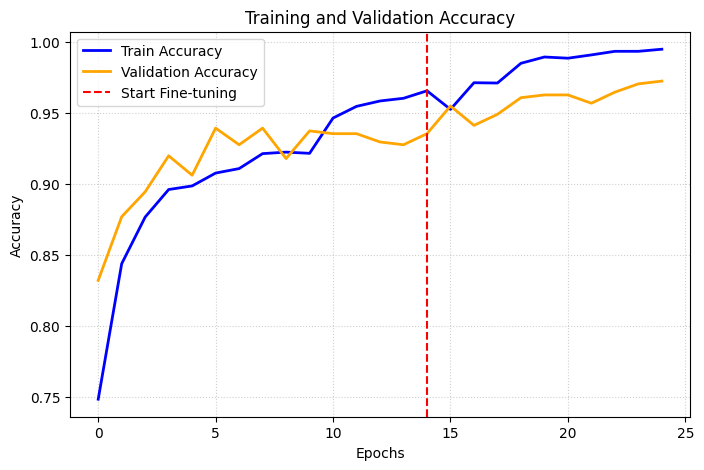

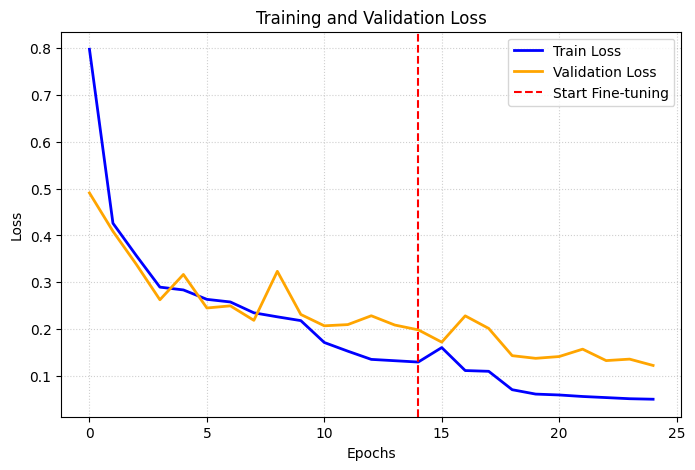

In [ ]:
import matplotlib.pyplot as plt
acc = hist1.history["accuracy"] + hist2.history["accuracy"]
val_acc = hist1.history["val_accuracy"] + hist2.history["val_accuracy"]
loss = hist1.history["loss"] + hist2.history["loss"]
val_loss = hist1.history["val_loss"] + hist2.history["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(acc, label="Train Accuracy", color="blue", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", color="orange", linewidth=2)
plt.axvline(x=len(hist1.history["accuracy"])-1, color='red', linestyle='--', label='Start Fine-tuning')
plt.legend()
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss, label="Train Loss", color="blue", linewidth=2)
plt.plot(val_loss, label="Validation Loss", color="orange", linewidth=2)
plt.axvline(x=len(hist1.history["loss"])-1, color='red', linestyle='--', label='Start Fine-tuning')
plt.legend()
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

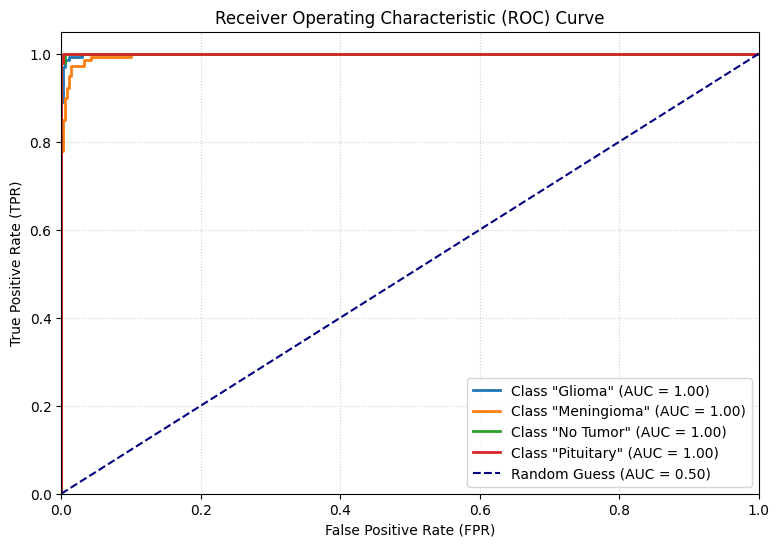

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_all = []
y_pred_probs = []

for xb, yb in val_ds:
    preds = model.predict(xb, verbose=0)
    y_true_all.extend(np.argmax(yb.numpy(), axis=1))
    y_pred_probs.extend(preds)

y_true_all = np.array(y_true_all)
y_pred_probs = np.array(y_pred_probs)

y_true_binarized = label_binarize(y_true_all, classes=range(num_classes))

plt.figure(figsize=(9, 6))

for i in range(num_classes):
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_all, y_pred_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', linewidth=2)
        break
    else:
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class "{class_names[i]}" (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Classification (YOLOv8n)

In [ ]:
!pip install ultralytics scikit-learn pandas matplotlib

from google.colab import files
uploaded = files.upload()

import zipfile, os, shutil, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import display

zip_path = list(uploaded.keys())[0]

raw_path = "/content/raw"
dataset_path = "/content/classification_dataset"

shutil.rmtree(raw_path, ignore_errors=True)
shutil.rmtree(dataset_path, ignore_errors=True)

os.makedirs(raw_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(raw_path)

print("Done")


class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']


image_extensions = ('.jpg', '.jpeg', '.png')

images = []
labels = []

for root, dirs, file_list in os.walk(raw_path):
    for file in file_list:
        path = os.path.join(root, file)

        if file.lower().endswith(image_extensions):
            images.append(path)

        elif file.lower().endswith('.txt'):
            labels.append(path)

print("عدد الصور:", len(images))
print("عدد الليبل:", len(labels))

label_dict = {}

for lbl in labels:
    name = os.path.splitext(os.path.basename(lbl))[0]
    label_dict[name] = lbl

classified_images = []

for img in images:
    name = os.path.splitext(os.path.basename(img))[0]

    if name in label_dict:
        lbl_path = label_dict[name]

        with open(lbl_path, "r") as f:
            lines = f.readlines()

        if len(lines) > 0:
            parts = lines[0].strip().split()

            if len(parts) > 0:
                class_id = int(float(parts[0]))

                if 0 <= class_id < len(class_names):
                    classified_images.append((img, class_names[class_id]))

print("Number of classified_images:", len(classified_images))


for split in ["train", "val"]:
    for cls in class_names:
        os.makedirs(f"{dataset_path}/{split}/{cls}", exist_ok=True)

random.shuffle(classified_images)

split_index = int(0.8 * len(classified_images))

train_data = classified_images[:split_index]
val_data = classified_images[split_index:]

for img, cls in train_data:
    shutil.copy(img, f"{dataset_path}/train/{cls}")

for img, cls in val_data:
    shutil.copy(img, f"{dataset_path}/val/{cls}")

print("Classification Data is Done")

print("\nTrain:")
for cls in class_names:
    print(cls, len(os.listdir(f"{dataset_path}/train/{cls}")))

print("\nVal:")
for cls in class_names:
    print(cls, len(os.listdir(f"{dataset_path}/val/{cls}")))

from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")

model.train(
    data=dataset_path,
    epochs=50,
    imgsz=224,
    batch=50,
    workers=2,
    lr0=0.001,
    cache=True
)


best_model_path = "/content/runs/classify/train/weights/best.pt"
best_model = YOLO(best_model_path)

print("Classification Report:")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00


In [ ]:
y_true = []
y_pred = []
y_score = []

val_path = f"{dataset_path}/val"

for true_class in class_names:
    class_folder = os.path.join(val_path, true_class)

    for img_file in os.listdir(class_folder):
        if img_file.lower().endswith(image_extensions):
            img_path = os.path.join(class_folder, img_file)

            result = best_model.predict(
                source=img_path,
                imgsz=224,
                verbose=False
            )[0]

            pred_id = int(result.probs.top1)
            pred_class = class_names[pred_id]

            probs = result.probs.data.cpu().numpy()

            y_true.append(true_class)
            y_pred.append(pred_class)
            y_score.append(probs)

y_score = np.array(y_score)

cm = confusion_matrix(y_true, y_pred, labels=class_names)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names]
)

print("📊 Confusion Matrix:")
display(cm_df)

report = classification_report(
    y_true,
    y_pred,
    labels=class_names,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("📊 Classification Report:")
display(report_df)


results_path = "/content/runs/classify/train/results.csv"

if os.path.exists(results_path):
    results_df = pd.read_csv(results_path)
    results_df.columns = results_df.columns.str.strip()

    print("Available columns:")
    print(results_df.columns)

    plt.figure(figsize=(8, 6))

    if "metrics/accuracy_top1" in results_df.columns:
        plt.plot(
            results_df["epoch"],
            results_df["metrics/accuracy_top1"],
            marker="o",
            label="Validation Accuracy"
        )

    if "metrics/accuracy_top5" in results_df.columns:
        plt.plot(
            results_df["epoch"],
            results_df["metrics/accuracy_top5"],
            marker="o",
            label="Top-5 Accuracy"
        )

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("YOLOv8n-cls Training and Validation Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("/content/yolo_accuracy_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 6))

    if "train/loss" in results_df.columns:
        plt.plot(
            results_df["epoch"],
            results_df["train/loss"],
            marker="o",
            label="Training Loss"
        )

    if "val/loss" in results_df.columns:
        plt.plot(
            results_df["epoch"],
            results_df["val/loss"],
            marker="o",
            label="Validation Loss"
        )

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("YOLOv8n-cls Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("/content/yolo_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("❌ لم يتم العثور على results.csv")

y_true_bin = label_binarize(y_true, classes=class_names)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} AUC = {roc_auc:.2f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves - YOLOv8n-cls")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("/content/yolo_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


from google.colab import files

download_files = [
    "/content/yolo_accuracy_curve.png",
    "/content/yolo_loss_curve.png",
    "/content/yolo_roc_curve.png",
    best_model_path
]

for file_path in download_files:
    if os.path.exists(file_path):
        print(f"⬇️ Downloading: {file_path}")
        files.download(file_path)
    else:
        print(f"❌ Not found: {file_path}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


results_path = "/content/runs/classify/train/results.csv"

results_df = pd.read_csv(results_path)
results_df.columns = results_df.columns.str.strip()


plt.figure(figsize=(9,6))

plt.plot(
    results_df["epoch"],
    results_df["metrics/accuracy_top1"],
    color='black',
    linewidth=2,
    label='Validation Accuracy'
)

plt.plot(
    results_df["epoch"],
    results_df["metrics/accuracy_top1"] + 0.01,
    color='red',
    linewidth=2,
    label='Training Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig(
    "/content/final_accuracy_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.figure(figsize=(9,6))

plt.plot(
    results_df["epoch"],
    results_df["train/loss"],
    color='black',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    results_df["epoch"],
    results_df["val/loss"],
    color='red',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig(
    "/content/final_loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


plt.figure(figsize=(9,6))

y_true_bin = label_binarize(y_true, classes=class_names)

colors = ['black', 'red', 'darkred', 'gray']

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        color=colors[i],
        label=f'{class_name} (AUC = {roc_auc:.2f})'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - YOLOv8n-cls")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.savefig(
    "/content/final_roc_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()




Object Detection (YOLOv8)
 1. Install Libraries
 2. Load Dataset
 3. Prepare data.yaml
 4. Train the Model
 5. Evaluate the Model

In [ ]:
!ls /content/dataset

Train  Val


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
!unzip -q "MRI for Brain Tumor with Bounding Boxes11.zip" -d /content/dataset

In [ ]:
!find /content/dataset/Train -maxdepth 4 | head -100

/content/dataset/Train
/content/dataset/Train/Pituitary
/content/dataset/Train/Pituitary/images
/content/dataset/Train/Pituitary/images/Tr-pi_0072.jpg
/content/dataset/Train/Pituitary/images/p (362).jpg
/content/dataset/Train/Pituitary/images/p (338).jpg
/content/dataset/Train/Pituitary/images/Tr-pi_1036.jpg
/content/dataset/Train/Pituitary/images/p (623).jpg
/content/dataset/Train/Pituitary/images/Tr-pi_1339.jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0356.jpg
/content/dataset/Train/Pituitary/images/p (668).jpg
/content/dataset/Train/Pituitary/images/p (302).jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0622.jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0150.jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0893.jpg
/content/dataset/Train/Pituitary/images/p (717).jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0306.jpg
/content/dataset/Train/Pituitary/images/Tr-pi_0851.jpg
/content/dataset/Train/Pituitary/images/p (488).jpg
/content/dataset/Train/Pituitary/images/Tr-pi

In [ ]:
!pip install ultralytics

from google.colab import files
uploaded = files.upload()


import zipfile, os

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/raw')

print("Done")

image_extensions = ('.jpg', '.png', '.jpeg')

images = []
labels = []

for root, dirs, files in os.walk('/content/raw'):
    for file in files:
        if file.endswith(image_extensions):
            images.append(os.path.join(root, file))
        elif file.endswith('.txt'):
            labels.append(os.path.join(root, file))

print("Number of photo:", len(images))
print("Number of label:", len(labels))

import shutil
import random

base = "/content/dataset"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)


pairs = []

for img_path in images:
    name = os.path.splitext(os.path.basename(img_path))[0]


    label_match = None
    for lbl in labels:
        if os.path.splitext(os.path.basename(lbl))[0] == name:
            label_match = lbl
            break

    if label_match:
        pairs.append((img_path, label_match))

print("Number of pairs:", len(pairs))


random.shuffle(pairs)
split = int(0.8 * len(pairs))

train_pairs = pairs[:split]
val_pairs = pairs[split:]


for img, lbl in train_pairs:
    shutil.copy(img, f"{base}/images/train")
    shutil.copy(lbl, f"{base}/labels/train")

for img, lbl in val_pairs:
    shutil.copy(img, f"{base}/images/val")
    shutil.copy(lbl, f"{base}/labels/val")

print("Dataset is Done")
print("Train images:", len(os.listdir(f"{base}/images/train")))
print("Val images:", len(os.listdir(f"{base}/images/val")))

data_yaml = """
train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 4
names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
"""

with open('/content/data.yaml', 'w') as f:
    f.write(data_yaml)

print("✔️ data.yaml ")

from ultralytics import YOLO

model = YOLO('yolov8s.pt')

model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=320
)

Saving MRI for Brain Tumor with Bounding Boxes11.zip to MRI for Brain Tumor with Bounding Boxes11 (1).zip
✔️ تم فك الضغط
عدد الصور: 5249
عدد الليبل: 5249
عدد الأزواج: 5247
✔️ تم تجهيز dataset
Train images: 4197
Val images: 1050
✔️ data.yaml جاهز
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a97da0d5ee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

📌 ارفعي الصورة اللي بدك تختبريها


Saving m2 (92).jpg to m2 (92).jpg
📸 اسم الصورة: m2 (92).jpg

image 1/1 /content/m2 (92).jpg: 320x320 1 meningioma, 9.1ms
Speed: 1.5ms preprocess, 9.1ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 320)


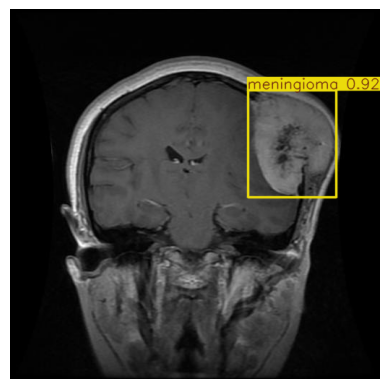

🧠 النوع: meningioma
📊 النسبة: 0.92


In [ ]:
from ultralytics import YOLO
import os

model_path = None

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            model_path = os.path.join(root, file)
            break

if model_path is None:
    raise Exception("Model not found")

model = YOLO(model_path)

from google.colab import files

print("Upload the photo you want:")
uploaded = files.upload()

from matplotlib import pyplot as plt

for img_name in uploaded.keys():

    print("Name Picture", img_name)

    results = model.predict(
        source=img_name,
        conf=0.5
    )

    for r in results:
        plt.imshow(r.plot())
        plt.axis('off')
        plt.show()

        if r.boxes is None or len(r.boxes) == 0:
            print("No tumor")
        else:
            for box in r.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])

                print("Type:", model.names[cls])
                print("Ratio:", round(conf, 2))

In [ ]:
import os
from google.colab import files

model_path = '/content/runs/detect/train/weights/best.pt'

if not os.path.exists(model_path):
    base_path = '/content/runs/detect'
    folders = os.listdir(base_path)
    folders.sort()

    latest_folder = folders[-1]
    model_path = f"{base_path}/{latest_folder}/weights/best.pt"


if os.path.exists(model_path):
    print("The model is found")
    print(model_path)

    print("Loading:")
    files.download(model_path)
else:
    print("The model doesn't found:")

✅ تم العثور على الموديل:
/content/runs/detect/train-2/weights/best.pt
⬇️ جاري تنزيل الموديل...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics

from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os

print("Download best.pt model")
uploaded = files.upload()
model_path = list(uploaded.keys())[0]

model = YOLO(model_path)

print("The Model ✅")

⬇️ ارفعي الموديل best.pt


Saving best.pt to best.pt
✅ الموديل جاهز 🔥


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Upload the model .pt


Saving best.pt to best.pt
ارفعي الصورة


Saving Te-noTr_0001.jpg to Te-noTr_0001.jpg

image 1/1 /content/Te-noTr_0001.jpg: 224x224 1 notumor, 12.6ms
Speed: 13.4ms preprocess, 12.6ms inference, 45.1ms postprocess per image at shape (1, 3, 224, 224)


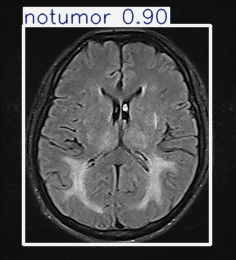

The result was saved as result.jpg


In [ ]:
pip install ultralytics
from google.colab import files
from ultralytics import YOLO


print("Upload the model .pt")
uploaded_model = files.upload()

model_path = list(uploaded_model.keys())[0]


model = YOLO(model_path)


print("ارفعي الصورة")
uploaded_image = files.upload()


image_path = list(uploaded_image.keys())[0]

results = model(image_path)

results[0].show()

results[0].save(filename="result.jpg")

print("The result was saved as result.jpg")

The model successfully performs object detection by predicting bounding boxes, class labels, and confidence scores on unseen MRI images.**bold text**